<a href="https://colab.research.google.com/github/T-Svitlichna/DTA_Python/blob/main/HomeWork/28062026_2practice_stat_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Статистичні тести: практикум

**Тривалість:** ~4 години · бібліотека `scipy.stats`

---

Цей практикум закріплює лекцію про p-значення та статистичну значущість. Він влаштований так:

- 🟦 **Теорія** — короткий блок перед кожним тестом: *коли* його обирати, *чому*, *як читати результат*.
- ✏️ **Завдання (код)** — ви пишете код, що проводить тест.
- 💬 **Інтерпретація** — ви **своїми словами** пояснюєте, що означає результат. Це найважливіша частина! Аналітик, який уміє порахувати p-значення, але не вміє його пояснити — це лише калькулятор.

## Як працювати
1. Читайте теоретичний блок.
2. Виконуйте завдання на код (Shift+Enter).
3. На кожне питання інтерпретації відповідайте **повним реченням людською мовою** — так, ніби пояснюєте керівнику без технічної освіти.

## Загальне правило
- `p < 0.05` → статистично значущо → відхиляємо H₀
- `p ≥ 0.05` → не значущо → не відхиляємо H₀

> 💡 Тримайте поруч шпаргалку вибору тесту з лекції. Половина завдань — про те, щоб **обрати правильний тест**.

---

## Підготовка

Запустіть цю клітинку. Ми працюємо з двома наборами даних:
- **`shop_customers.csv`** — 500 клієнтів інтернет-магазину
- **`ab_test.csv`** — результати A/B-тесту (8000 сесій)


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("shop_customers.csv")
ab = pd.read_csv("ab_test.csv")

print("Клієнти:", df.shape)
print("A/B тест:", ab.shape)
df.head()

Клієнти: (500, 11)
A/B тест: (8000, 3)


,customer_id,gender,age,country,channel,device,spend,session_min,sat_before,sat_after,purchased
0,1001,Ч,23,Німеччина,Реклама,Desktop,997.11,22.2,6,7,Так
1,1002,Ч,38,Україна,Органіка,Desktop,510.09,19.8,5,8,Ні
2,1003,Ч,20,Україна,Соцмережі,Desktop,789.71,21.0,7,8,Ні
3,1004,Ч,40,Німеччина,Соцмережі,Desktop,1041.02,17.4,8,9,Ні
4,1005,Ч,18,Україна,Реклама,Desktop,944.34,23.5,6,7,Ні


### Опис даних `shop_customers.csv`

| Стовпець | Опис | Тип |
|---|---|---|
| `customer_id` | ID клієнта | — |
| `gender` | Стать (Ч/Ж) | категоріальний |
| `age` | Вік | числовий |
| `country` | Країна | категоріальний |
| `channel` | Канал залучення (Органіка/Реклама/Соцмережі) | категоріальний |
| `device` | Пристрій (Mobile/Desktop) | категоріальний |
| `spend` | Витрати клієнта, грн | числовий |
| `session_min` | Час на сайті, хв | числовий |
| `sat_before` | Задоволеність ДО редизайну (1-10) | числовий |
| `sat_after` | Задоволеність ПІСЛЯ редизайну (1-10) | числовий |
| `purchased` | Чи зробив покупку (Так/Ні) | категоріальний |

Спочатку завжди корисно роздивитись дані.

#### ✏️ Завдання 1 (код)

Виведіть основну статистику по числових стовпцях (підказка: метод `.describe()`).

In [3]:
# Завдання 1:
df.describe()

,customer_id,age,spend,session_min,sat_before,sat_after
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,34.646000,845.016340,20.739400,6.536000,7.138000
std,144.481833,10.961615,333.460589,10.532489,1.523597,1.826919
min,1001.000000,18.000000,50.000000,1.000000,2.000000,1.000000
25%,1125.750000,26.000000,612.627500,13.100000,6.000000,6.000000
50%,1250.500000,34.000000,834.750000,20.850000,7.000000,7.000000
75%,1375.250000,41.250000,1070.395000,27.400000,8.000000,9.000000
max,1500.000000,69.000000,1952.020000,52.200000,10.000000,10.000000


#### ✏️ Завдання 2 (код)

Скільки клієнтів у кожному каналі залучення? (підказка: `.value_counts()` на стовпці `channel`)

In [4]:
# Завдання 2:
df.value_counts('channel')

,count
channel,
Органіка,174
Соцмережі,167
Реклама,159


---
# Розділ 1. Одновибірковий t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли у вас є **одна** група числових даних, і ви хочете порівняти її **середнє** з якимось **фіксованим, наперед відомим числом** (ціль, норматив, заявлене значення).

**Чому саме він:** ми перевіряємо, чи відхилення нашого середнього від цільового числа реальне, чи це випадковість вибірки.

**Гіпотези:**
- H₀: середнє = цільове число
- H₁: середнє ≠ цільове число

**Функція:** `stats.ttest_1samp(дані, цільове_число)`

**Як читати:** дивимось на p-значення. Якщо `p < 0.05` — середнє значущо відрізняється від цільового.

**Приклад із життя:** виробник заявляє, що пакет чипсів важить 100 г. Ви зважили 50 пакетів. Чи справді середня вага = 100 г, чи вас обманюють?

**Сценарій:** маркетолог стверджує, що середній час на сайті становить 20 хвилин. Перевіримо це.

#### ✏️ Завдання 3 (код)

Порахуйте фактичний середній `session_min`. Потім проведіть одновибірковий t-тест, щоб перевірити, чи відрізняється він від 20. Виведіть t-статистику та p-значення.

In [5]:
# Завдання 3:
session_min = df['session_min'].mean()
print(session_min)
stat, p_value = stats.ttest_1samp(df['session_min'], 20)
print(f"F-statistic: {stat:.3f}, p-value: {p_value:.5f}")


20.7394
F-statistic: 1.570, p-value: 0.11710


#### 💬 Інтерпретація 1

Чи відрізняється середній час на сайті від заявлених 20 хвилин? Сформулюйте висновок для маркетолога: він мав рацію чи ні? Чому ви так вважаєте (спирайтесь на p-значення)?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**:

*Суттєвої різниці дійсно немає, значення р > 0,05 та реальний середній показник це підтверджує з невеликим відхиденням 0,7хв. Ми не відхтляємо нульову теорію,  різниця невелика є але статистично не значущаю

**Другий сценарій:** керівник вважає, що середні витрати клієнта = 850 грн.

#### ✏️ Завдання 4 (код)

Перевірте за допомогою одновибіркового t-тесту, чи середні витрати (`spend`) відрізняються від 850 грн.

In [6]:
# Завдання 4:
spend_avg = df['spend'].mean()
print(spend_avg)
stat, p_value = stats.ttest_1samp(df['spend'], 850)
print(f"F-statistic: {stat:.3f}, p-value: {p_value:.5f}")

845.01634
F-statistic: -0.334, p-value: 0.73838


#### 💬 Інтерпретація 2

Що показав тест? Чи можна сказати, що середні витрати дорівнюють 850 грн? Поясніть, чому тут ми НЕ відхиляємо нульову гіпотезу (зверніть увагу на формулювання: чи це означає, що середнє точно дорівнює 850?).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*За результатами тесту ми погоджуємося з що середні витрати приблизно 850 грн, різниця між заданим та розрахованим не має статистичної значущості. Тому ми не видхтляємо нульому теорію*

---
# Розділ 2. Двовибірковий t-тест (незалежні групи)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте **середні двох РІЗНИХ, незалежних груп** числових даних.

**Чому саме він:** хочемо дізнатись, чи різниця між групами реальна, чи могла виникнути випадково.

**Ключова умова — групи НЕЗАЛЕЖНІ:** різні люди в кожній групі (на відміну від парного тесту, де ті самі люди двічі).

**Гіпотези:**
- H₀: середнє групи 1 = середнє групи 2
- H₁: вони відрізняються

**Функція:** `stats.ttest_ind(група1, група2)`

**Приклад із життя:** чи відрізняється середня зарплата у двох відділах? Чи витрачають більше клієнти з міста А порівняно з містом Б?

**Сценарій:** чи витрачають клієнти з мобільних більше, ніж з десктопу?

#### ✏️ Завдання 5 (код)

Розділіть `spend` на дві групи за `device` (Mobile та Desktop). Виведіть середнє кожної групи і проведіть двовибірковий t-тест.

In [7]:
# Завдання 5:
group_mobile = df[df['device'] == 'Mobile']['spend']
group_desktop = df[df['device'] == 'Desktop']['spend']
print(group_mobile.mean())
print(group_desktop.mean())
stat, p_value = stats.ttest_ind(group_mobile, group_desktop)
print(f"F-statistic: {stat:.3f}, p-value: {p_value:.5f}")

835.2062057877814
861.1589417989417
F-statistic: -0.844, p-value: 0.39930


#### 💬 Інтерпретація 3

Чи є значуща різниця у витратах між Mobile та Desktop? Якби ви були аналітиком, чи порадили б компанії інвестувати в мобільну версію на основі цього результату?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Відповідно до проведеного аналізу статистично значущої різниці не виявлено. Сенсу інвестувати в один із девайсів немає. Тип пристрою взагаді не впливає на витрати. Різниця між середніми значеннями виникнула випадково.

**Сценарій:** чи різниться час на сайті залежно від статі?

#### ✏️ Завдання 6 (код)

Порівняйте `session_min` між чоловіками та жінками за допомогою двовибіркового t-тесту.

In [8]:
# Завдання 6:
group_male = df[df['gender'] == 'Ч']['session_min']
group_female = df[df['gender'] == 'Ж']['session_min']
print(group_male.mean().round(2))
print(group_female.mean().round(2))
stat, p_value = stats.ttest_ind(group_male, group_female)
print(f"F-statistic: {stat:.3f}, p-value: {p_value:.5f}")

20.85
20.63
F-statistic: 0.232, p-value: 0.81634


#### 💬 Інтерпретація 4

Сформулюйте висновок. Якщо різниця не значуща — що це означає на практиці для команди маркетингу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Відповідно до проведеного аналізу статистично значущої різниці не виявлено p-value: 0.81634. Час на сайті проводять однаково як чоловіки так і жінки, різниця між середніми значеннями не повязана та не має статистичної значимості. Для обох груп варто робити однакові маркетингові компаніх не розділяючи вибірку на чоловіків та жінок

---
# Розділ 3. Парний t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви маєте **два виміри в ОДНИХ І ТИХ САМИХ обʼєктів** — типово «до і після» якоїсь зміни.

**Чому саме він (а не звичайний t-тест):** виміри пов'язані (той самий клієнт до і після). Парний тест враховує цей зв'язок і тому **потужніший** — він краще виявляє реальні зміни.

**Гіпотези:**
- H₀: середня різниця (після − до) = 0 (зміни немає)
- H₁: середня різниця ≠ 0 (зміна є)

**Функція:** `stats.ttest_rel(до, після)`

**Приклад із життя:** вага пацієнтів до і після дієти. Продуктивність працівників до і після тренінгу. Бали студентів до і після курсу.

> ⚠️ Головна підказка для вибору: якщо ви бачите слова «до/після», «був/став», «той самий обʼєкт двічі» — це парний тест.

**Сценарій:** компанія зробила редизайн сайту і виміряла задоволеність тих самих клієнтів до (`sat_before`) і після (`sat_after`).

#### ✏️ Завдання 7 (код)

Проведіть парний t-тест, щоб перевірити, чи змінилася задоволеність клієнтів після редизайну. Виведіть середні значення до і після, а також p-значення.

In [9]:
# Завдання 7:
print(df[['sat_after','sat_before']].agg(['mean']))
stat, p_value = stats.ttest_rel(df['sat_after'], df['sat_before'])
print(f"F-statistic: {stat:.3f}, p-value: {p_value:.5f}")

      sat_after  sat_before
mean      7.138       6.536
F-statistic: 11.303, p-value: 0.00000


In [10]:
#tt-test_ind
print(df[['sat_before','sat_after']].agg(['mean']))
stat, p_value = stats.ttest_ind(df['sat_after'], df['sat_before'])
print(f"F-statistic: {stat:.3f}, p-value: {p_value:.5f}")

      sat_before  sat_after
mean       6.536      7.138
F-statistic: 5.659, p-value: 0.00000


#### 💬 Інтерпретація 5

Чи спрацював редизайн? Поясніть, чому тут доречний саме ПАРНИЙ тест, а не звичайний двовибірковий. Що було б не так, якби ми використали `ttest_ind`?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Парний редизайн спрацював, значення покращилось. Різницю також підтверджено p-value: 0.00000. Тут доречний парний тест, тому що він порівнює кожне значення з двох груп між собою. А двовибірковий тест розглядає  2 групи як незалежні і потім порівнює їх значення. Як видно вище, показник F-statistic менш чутливий.

---
# Розділ 4. ANOVA (дисперсійний аналіз)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте середні **ТРЬОХ або більше груп** числових даних.

**Чому не кілька t-тестів:** якби ми порівнювали групи попарно багатьма t-тестами, ми б накопичили помилки I роду (згадайте проблему множинних порівнянь!). ANOVA перевіряє все одним тестом.

**Гіпотези:**
- H₀: середні ВСІХ груп однакові
- H₁: принаймні одна група відрізняється

**Функція:** `stats.f_oneway(група1, група2, група3, ...)`

**Важливе обмеження:** ANOVA каже, що різниця Є, але не каже, **між якими саме** групами. Для цього потрібні додаткові (post-hoc) тести.

**Приклад із життя:** чи відрізняється врожайність при трьох різних добривах? Чи різний середній дохід у чотирьох регіонах?

**Сценарій:** чи залежать витрати клієнта від каналу залучення (Органіка / Реклама / Соцмережі)?

#### ✏️ Завдання 8 (код)

Виведіть середні `spend` для кожного каналу. Потім проведіть ANOVA, щоб перевірити, чи є значуща різниця між каналами. (Підказка: створіть список груп через цикл або вручну, потім передайте їх у `f_oneway`.)

In [11]:
# Завдання 8:
avg_ch_spend = df.groupby('channel')['spend'].mean().round().sort_values()
print(avg_ch_spend)
stat, p_value = stats.f_oneway(df[df['channel'] == 'Органіка']['spend'], df[df['channel'] == 'Реклама']['spend'], df[df['channel'] == 'Соцмережі']['spend'])

print(f"F-statistic: {stat:.3f}, p-value: {p_value:.5f}")

channel
Соцмережі     698.0
Органіка      791.0
Реклама      1058.0
Name: spend, dtype: float64
F-statistic: 63.540, p-value: 0.00000


#### 💬 Інтерпретація 6

Чи відрізняються канали за витратами? Який канал виглядає найприбутковішим? Чому на основі лише ANOVA ми НЕ можемо точно сказати, що, наприклад, Реклама значущо краща за Органіку?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*ANOVA тест показує, що є різниця між групами, але не показує між якими саме. Для цього потрібно розглядати окремо кожну пару груп. Відповідно за виведеними данними - канали відрізняються за групами, лідирує канал "Реклама". Однак стверджувати що Реклама значущо краща за Органіку не можна — для цього потрібен інший тест.*

**Сценарій:** чи залежить час на сайті (`session_min`) від країни клієнта?

#### ✏️ Завдання 9 (код)

Проведіть ANOVA для `session_min` за трьома країнами (`country`).

In [12]:
# Завдан 9
sees_country = df.groupby('country')['session_min'].mean().round().sort_values()
print(sees_country)
stat, p_value = stats.f_oneway(df[df['country'] == 'Україна']['session_min'],df[df['country'] == 'Німеччина']['session_min'], df[df['country'] == 'Польща']['session_min'])

print(f"F-statistic: {stat:.3f}, p-value: {p_value:.5f}")

country
Україна      20.0
Німеччина    21.0
Польща       21.0
Name: session_min, dtype: float64
F-statistic: 0.493, p-value: 0.61108


#### 💬 Інтерпретація 7

Що показав результат? Сформулюйте висновок про звʼязок країни і часу на сайті.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Відповідно до проведеного тесту, видно що звязку між групами та часу проведеного на сайті немає, це також видно з виведених середніх даних та показників F-statistic: 0.493, p-value: 0.61108.

---
# Розділ 5. Хі-квадрат (χ²)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **категоріальні**, і ви хочете перевірити, чи є між ними **звʼязок**.

**Чому саме він:** t-тест і ANOVA працюють із числами (середніми). Коли даних немає що усереднювати (категорії на кшталт «купив/не купив», «місто», «колір»), використовують хі-квадрат на основі **частот**.

**Гіпотези:**
- H₀: змінні незалежні (звʼязку немає)
- H₁: змінні повʼязані

**Як проводити (два кроки):**
1. Побудувати таблицю спряженості: `pd.crosstab(змінна1, змінна2)`
2. Передати її у `stats.chi2_contingency(таблиця)` — повертає chi2, p, dof, expected

**Приклад із життя:** чи повʼязана стать із вибором категорії товару? Чи залежить рішення про покупку від кольору кнопки (це і є A/B-тест для конверсій!)?

**Сценарій:** чи повʼязаний канал залучення (`channel`) із фактом покупки (`purchased`)?

#### ✏️ Завдання 10 (код)

Побудуйте таблицю спряженості між `channel` та `purchased`, виведіть її, потім проведіть тест хі-квадрат.

In [13]:
# Завдання 10:
chan_purch = pd.crosstab(df['channel'], df['purchased']) # tab spr
print(chan_purch)
stat, p_value, dof, expected = stats.chi2_contingency(chan_purch)
print(f"ch2: {stat:.3f}, p-value: {p_value:.5f}")

purchased   Ні  Так
channel            
Органіка   116   58
Реклама    110   49
Соцмережі  107   60
ch2: 0.957, p-value: 0.61975


#### 💬 Інтерпретація 8

Чи виявив тест звʼязок між каналом залучення та покупкою? Сформулюйте висновок. Якщо звʼязку не виявлено — що це означає для бізнесу (чи варто обирати канал, орієнтуючись на ймовірність покупки)? Якщо звʼязок є — подивіться на частки в таблиці спряженості й опишіть, який канал вигідніший.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Тест не виявив звʼязок між каналом залучення та покупкою. Наразі кількість покупок не залежить від каналів залученості. ЯВарто шукати інші фактори, які впливати на покупки.

**Сценарій:** чи повʼязана стать (`gender`) із вибором пристрою (`device`)?

#### ✏️ Завдання 11 (код)

Перевірте за допомогою хі-квадрат, чи є звʼязок між статтю та пристроєм.

In [14]:
# Завдання 11:
dev_gen = pd.crosstab(df['gender'], df['device']) # tab spr
print(chan_purch)
stat, p_value, dof, expected = stats.chi2_contingency(dev_gen)
print(f"ch2: {stat:.3f}, p-value: {p_value:.5f}")

purchased   Ні  Так
channel            
Органіка   116   58
Реклама    110   49
Соцмережі  107   60
ch2: 0.065, p-value: 0.79935


#### 💬 Інтерпретація 9

Сформулюйте висновок. Чи можна за цими даними сказати, що чоловіки й жінки користуються різними пристроями?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

За результатами проведеного тесту, видно, що різниці в користуваннями девайсами між чоловіками та жінка не виямлено. ch2: 0.065, p-value: 0.79935. Клієнти обох статей користуються пристороями незалежно. Тобто стать не впливає на вибір пристрою.


---
# Розділ 6. Кореляція

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **числові**, і ви хочете виміряти **силу та напрямок звʼязку** між ними.

**Що повертає:** коефіцієнт кореляції **r** (від −1 до +1) ТА p-значення.
- **r ≈ +1** — сильний прямий звʼязок (одне зростає → інше зростає)
- **r ≈ −1** — сильний зворотний звʼязок (одне зростає → інше спадає)
- **r ≈ 0** — звʼязку немає
- **p-значення** — чи є цей звʼязок статистично значущим

**Функція:** `stats.pearsonr(змінна1, змінна2)`

**Гіпотези:**
- H₀: кореляції немає (r = 0)
- H₁: кореляція є (r ≠ 0)

> ⚠️ **Найважливіше попередження:** кореляція ≠ причинність! Значуща кореляція каже, що звʼязок реальний, але НЕ каже, що одне СПРИЧИНЯЄ інше.

**Приклад із життя:** чи повʼязаний зріст із вагою? Чи більше реклами → більше продажів?

**Сценарій:** чи повʼязаний час на сайті (`session_min`) із витратами (`spend`)?

#### ✏️ Завдання 12 (код)

Порахуйте кореляцію Пірсона між `session_min` та `spend`. Виведіть коефіцієнт r та p-значення. Додатково: побудуйте діаграму розсіювання (scatter plot), щоб побачити звʼязок очима.

             session_min     spend
session_min     1.000000  0.732246
spend           0.732246  1.000000


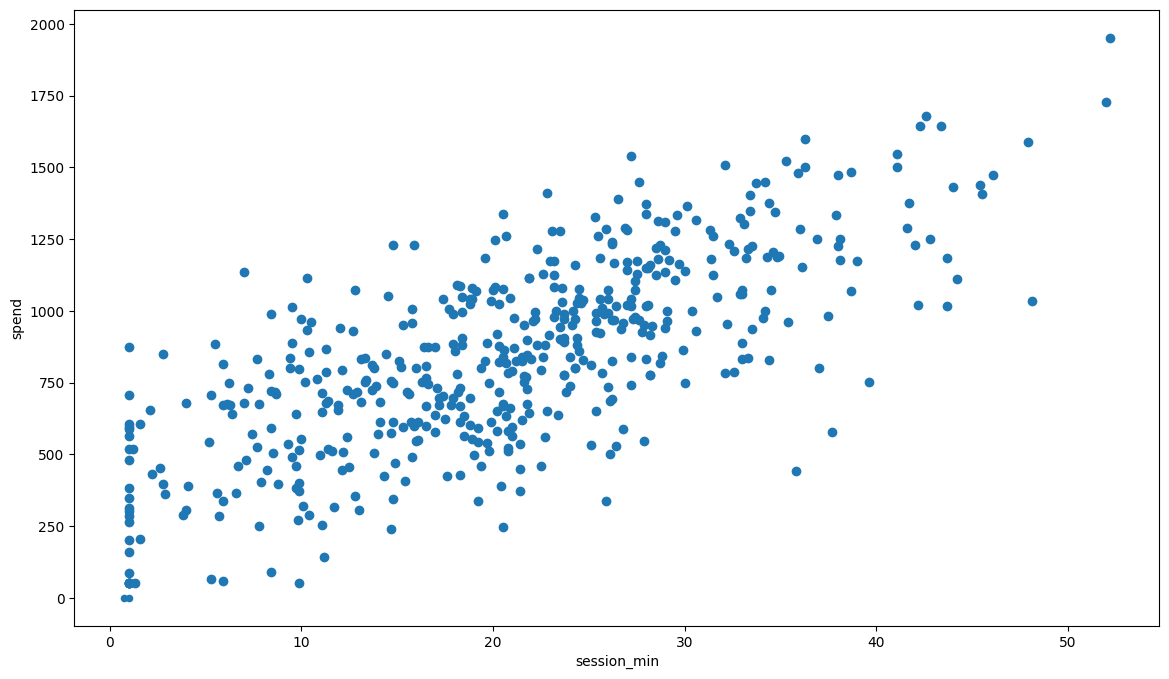

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [15]:
# Завдання 12:
session_min_spend = df[['session_min', 'spend']].corr()
print(session_min_spend)
session_min_spend.plot.scatter(x='session_min', y='spend',  figsize=(14, 8))
x = df['session_min']
y = df['spend']
plt.scatter(x, y)
plt.xlabel('session_min')
plt.ylabel('spend')
plt.show()
print

#### 💬 Інтерпретація 10

Опишіть звʼязок: він прямий чи зворотний? Сильний чи слабкий? Значущий? І найголовніше: чи можна стверджувати, що довший час на сайті СПРИЧИНЯЄ більші витрати? Поясніть свою думку.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Мфж часом проведеним на сайті та витратами виявлено сильний прямий зв'язок (r = 0.Між часом на сайті та витратами виявлено сильний прямий зв'язок (r = 0.73), що означає — чим довше клієнт на сайті, тим більше він витрачає. Однак стверджувати що довший час спричиняє більші витрати не можна, адже кореляція не доводить саме цей звязок, можливо обидва показники залежать від третього фактору, цікавість продуктом, збір інформації перед здійсненням дорогої  покупки

**Сценарій:** чи повʼязаний вік клієнта (`age`) з його витратами (`spend`)?

#### ✏️ Завдання 13 (код)

Порахуйте кореляцію між `age` та `spend`.

            age     spend
age    1.000000 -0.041817
spend -0.041817  1.000000


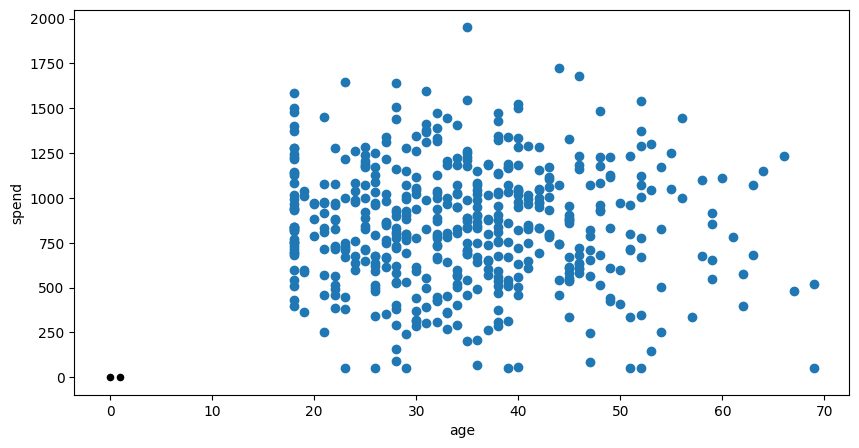

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [16]:
# Завдання 13:
age_spend = df[['age', 'spend']].corr()
print(age_spend)
age_spend.plot.scatter(x='age', y='spend',  figsize=(10, 5), color="Black")
x = df['age']
y = df['spend']
plt.scatter(x, y)


plt.xlabel('age')
plt.ylabel('spend')
plt.show()
print

#### 💬 Інтерпретація 11

Що показала кореляція? Порівняйте цей результат із попереднім (час на сайті vs витрати). У якому випадку звʼязок сильніший і чому це важливо для бізнесу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**
Між віком клієнта та його витратами звязку практично немає (r = -0.04) — вік не є фактором який впливає на суму покупки. Звязок відємний, це нормально для цього показника. Це значить що є товари які підходять для всіх груп клієнтів.

---
# Розділ 7. 🔥 Велике завдання: A/B-тест

## 🟦 Теорія: A/B-тестування

Це головне застосування статистики в аналітиці. Ми порівнюємо дві версії (A — контроль, B — варіант) і перевіряємо, чи нова версія справді краща, чи різниця випадкова.

Оскільки результат тут — **категоріальний** (конвертувався / ні), ми використовуємо **хі-квадрат** на таблиці спряженості «група × конверсія».

**Дані `ab_test.csv`:**
- `session_id` — ID сесії
- `group` — A (стара версія) або B (нова версія)
- `converted` — 1 (купив) або 0 (не купив)

Це повноцінне завдання, що імітує реальну роботу аналітика. Виконуйте крок за кроком.

**Крок 1. Дослідіть дані.**

#### ✏️ Завдання 14 (код)

Подивіться на дані `ab`: скільки сесій у групі A і скільки в групі B? (підказка: `value_counts` на `group`)

In [29]:
# Завдання 14:

ab.value_counts("group")

,count
group,
A,4000
B,4000


**Крок 2. Порахуйте конверсію кожної групи.**

Конверсія = частка тих, хто купив = середнє значення стовпця `converted` (бо це 0 і 1).

In [33]:
ab.groupby('group')['converted'].mean()*100
#ab.groupby('group')['converted'].sum()

,converted
group,
A,10.1
B,11.9


#### ✏️ Завдання 15 (код)

Порахуйте конверсію (середнє `converted`) для групи A і для групи B окремо. (Підказка: `ab.groupby('group')['converted'].mean()`) На скільки відсоткових пунктів відрізняється конверсія?

In [34]:
# Завдання 15:
ab.groupby('group')['converted'].mean()*100
#ab.groupby('group')['converted'].sum()

,converted
group,
A,10.1
B,11.9


#### 💬 Інтерпретація 12

Яка група показує вищу конверсію? Чи означає ця різниця в числах, що версія B точно краща? Чому ми НЕ можемо зробити висновок лише з цих чисел, без статистичного тесту?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*З вищенаведеної таблиці видно, що група В має вищу конверсію за групу А з різницею в 1,8%. Різниця не суттєва та може бути випадковою, тому не можна точно сказати чи насправді група В в плані конверсії краща.  Це можна перевірити застосувавши спеціальний , який покаже чи значуща статистично ця різниця чи випадкова .


**Крок 3. Сформулюйте гіпотези.**

#### 💬 Інтерпретація 13

Запишіть нульову (H₀) та альтернативну (H₁) гіпотези для цього A/B-тесту своїми словами.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Перевіримо гіпотизу за якою H₀ - ми вважаємо, що різниця випадкова,та H₁ - різниця не випадкова, а результат застосованих компанією змін/акцій тощо.

**Крок 4. Проведіть тест.**

#### ✏️ Завдання 16 (код)

Побудуйте таблицю спряженості `group` × `converted` і проведіть тест хі-квадрат. Виведіть таблицю та p-значення.

In [36]:
# Завдання 16:
tab_ab = pd.crosstab(ab['group'], ab['converted'])
print(tab_ab)
stat, p_value, dof, expected = stats.chi2_contingency(tab_ab)
print(f"ch2: {stat:.3f}, p-value: {p_value:.5f}")

converted     0    1
group               
A          3596  404
B          3524  476
ch2: 6.436, p-value: 0.01118


**Крок 5. Висновок.


#### 💬 Інтерпретація 14

На основі p-значення: чи є різниця між версіями статистично значущою (при α = 0.05)? Який ваш висновок — впроваджувати версію B чи ні? Сформулюйте фінальну рекомендацію для продуктової команди одним абзацом, як справжній аналітик.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**
За результатами тесту, виявлено, що різниця конверсії між групою А та В не випадкова і зміни дійсно привели до її збільшеню (р > 0,05).
*Компанія має вирішити, чи значення в 1,8% дійсно значиме для неї, чи варто покращити стратегію, щоб довести цей показник до більшого зачення.*

---
# Розділ 8. 🧠 Обери тест сам

## 🟦 Теорія

Найважливіша навичка аналітика — не запам'ятати функції, а вміти **обрати правильний тест** для задачі. У цьому розділі ми НЕ підказуємо тест — ви маєте визначити його самі.

**Алгоритм вибору:**
1. Який тип даних на виході? (числовий чи категоріальний)
2. Скільки груп / змінних порівнюємо?
3. Це незалежні групи чи «до/після» в тих самих об'єктів?

Кожне завдання: спочатку у клітинці інтерпретації **назвіть тест і поясніть вибір**, потім напишіть код.

**Задача A.** Компанія хоче знати, чи відрізняється середній вік клієнтів у трьох каналах залучення.

#### 💬 Інтерпретація 15

Який тест ви оберете і чому? (Спочатку відповідь, потім код нижче.)

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Для групи з 3 та більше клієнтів, я обраю (ANOVA) тест, щоб порівняти середнє числоаої змінної між каналами залучення.*

#### ✏️ Завдання 17 (код)

Проведіть обраний тест для задачі A (вік за каналами).

In [43]:
df.groupby('channel')['age'].mean().round().sort_values() #середнє для наглядності

,age
channel,
Органіка,34.0
Соцмережі,34.0
Реклама,35.0


In [42]:
# Завдання 17:
groups_channel = [df[df['channel'] == 'Органіка']['age'],
                  df[df['channel'] == 'Реклама']['age'],
                  df[df['channel'] == 'Соцмережі']['age']]

stat, p_value = stats.f_oneway(*groups_channel)
print(f"F-statistic: {stat:.3f}, p-value: {p_value:.5f}")

F-statistic: 0.599, p-value: 0.54984


#### 💬 Інтерпретація 16

Що показав результат? Сформулюйте висновок.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*За результатом проведення тесту,  виявлено, що залежності між віком та вибором гаджета немає, різниця суто випадкова. Значення (F-statistic: 0.599, p-value: 0.54984 >0,05 значно вищий та F показник дуже низький) *

**Задача B.** Маркетолог стверджує, що середні витрати клієнтів дорівнюють 900 грн.

#### 💬 Інтерпретація 17

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Для цього завдання підходить одновибірковий ttest, нам потрібно порівняти зразок - числове середнє значення з розрахунками

#### ✏️ Завдання 18 (код)

Проведіть обраний тест для задачі B.

In [44]:
# Завдання 18:
avg_cost = df['spend'].mean()
print(avg_cost)
stat, p_value = stats.ttest_1samp(df['spend'], 900)
print(f"F-statistic: {stat:.3f}, p-value: {p_value:.5f}")

845.01634
F-statistic: -3.687, p-value: 0.00025


#### 💬 Інтерпретація 18

Висновок: маркетолог має рацію?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*За результатами проведеного тесту виявлено, що середня становить 845 грн і ця різниця між заявленим значенням 900 не випадкова (F-statistic: -3.687, p-value: 0.00025). Маркетолог помилився. *

**Задача C.** Чи повʼязана країна клієнта (`country`) з пристроєм (`device`)?

#### 💬 Інтерпретація 19

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Коли нам потрібно знайти взаємозвязок між категоріальними значеннями ми використовуємо Хі-квадрат тест*

#### ✏️ Завдання 19 (код)

Проведіть обраний тест для задачі C.

In [52]:
# Завдання 19:
tab = pd.crosstab(df['country'], df['device'])
print(tab)
tab.div(tab.sum(axis=1),axis=0)*100

stat, p_value, dof, expected = stats.chi2_contingency(tab)
print("-" * 29)
print(f"chi2: {stat:.3f}, p-value: {p_value:.5f}")


device     Desktop  Mobile
country                   
Німеччина       46      63
Польща          49      82
Україна         94     166
-----------------------------
chi2: 1.207, p-value: 0.54699


#### 💬 Інтерпретація 20

Висновок про звʼязок країни та пристрою.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*За результатами проведеного тесту виявлено (p = 0.547 > 0.05) , що взаємозвязку між країнами та вибором девайсу не виявлено, різниця випадкова, або на вибір девайсу впливають інші фактори.

**Задача D.** Чи повʼязаний вік клієнта з часом, який він проводить на сайті?

#### 💬 Інтерпретація 21

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*В цьому завдання ми маємо знайти взаємозвязок між двому числовими змінними, хоча вік не класична числова змінна її не можна складати, але можна інші операції робити, притаманні числам. Тому для цього завдання підходить кореляція - *

#### ✏️ Завдання 20 (код)

Проведіть обраний тест для задачі D.

In [57]:
# Завдання 20:
r,p = stats.pearsonr(df['age'], df['session_min'])
print(f"r: {r:.3f}, p: {p:.5f}")

r: -0.012, p: 0.78982


#### 💬 Інтерпретація 22

Опишіть звʼязок (напрямок, сила, значущість).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*За результатом проведеного тесту, залежності між віком та часом проведеним за переглядом не виявлено (r: -0.012, p: 0.78982). Виведені коєфіцієнти показують повну незалежність. Існуюча ріниця випадкова. На час перегляду можуть впливати іншіфактори.

---
# 🎉 Вітаємо із завершенням!

Ви пройшли повний цикл роботи аналітика зі статистичними тестами:

- ✅ Одновибірковий, двовибірковий та парний t-тести
- ✅ ANOVA для 3+ груп
- ✅ Хі-квадрат для категоріальних даних
- ✅ Кореляція для числових змінних
- ✅ Повноцінний A/B-тест
- ✅ Самостійний вибір тесту під задачу

## Головне, що варто винести

1. **Вибір тесту** важливіший за код. Завжди питайте: який тип даних? скільки груп? незалежні чи парні?
2. **p-значення** саме по собі — це лише число. Цінність створює ваша **інтерпретація**.
3. **Контекст вирішує:** памʼятайте про розмір ефекту, практичну значущість і те, що кореляція ≠ причинність.

## Питання для самоперевірки
- Чи можете ви пояснити різницю між парним і двовибірковим t-тестом?
- Чому не можна замінити одну ANOVA трьома t-тестами?
- Що означає «не відхилили H₀» — чи це те саме, що «довели, що ефекту немає»?

Якщо на всі три питання ви відповідаєте впевнено — ви добре засвоїли тему. Так тримати! 📊
